# FallOff

In [1]:
# --------------------------------------------------------
# Import packages
# --------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from diffPLOG2TROE.parametrization import FallOff

- Equations
    > $k_f \: (T, P) = k_{\infty} \left(\dfrac{P_{r}}{1+P_{r}}\right)F(T, P_r) $
    >
    > - $P_r$ is the reduce pressure computed as follow: $P_r = \dfrac{k_{0}[M]}{k_{\infty}}$
    > - $[M]$ is the concentration of the mixture, possibly including enhanced third-body efficiencies.
    > - $k_0$ and $k_{\infty}$ are the low pressure and high pressure limits of the rate constant computed as a classic Arrhenius constant.
    >
    > - $F(T, P_r)$ is the falloff function that depending on different formalism is computed in different ways.

## Lindemann
- Equations
    > $F = 1$
- CHEMKIN representation
    >```
    > H + C2H4(+M) = C2H5(+M)    0.221E+14  0.000  2066.0   ! Michael
    >  LOW /                     6.369E+27 -2.760 -54.000 / ! Lindemann
    > H2/ 2/ CO/ 2/ CO2/ 3/ H2O/ 5/                         ! enhanced third-body efficiencies
    >```
- Internal representation
    >```python
    >lindemann_constant = {
    >    "name": "H+C2H4(+M)=C2H5(+M)",
    >    "type": "falloff",
    >    "falloff-type": "lindemann",
    >    "rate-constant": {
    >        "lpl-coefficients": [6.369e+27, -2.760, -54.000],
    >        "hpl-coefficients": [0.221e+14, 0.000, 2066.0],
    >    }
    >}

In [2]:
# --------------------------------------------------------
# Dictionary initialization
# --------------------------------------------------------
lindemann_constant = {
   "name": "H+C2H4(+M)=C2H5(+M)",
   "type": "falloff",
   "falloff-type": "lindemann",
   "rate-constant": {
       "lpl-coefficients": [6.369e+27, -2.760, -54.000],
       "hpl-coefficients": [0.221e+14, 0.000, 2066.0],
   }
}
rate_constant = FallOff(lindemann_constant)

# --------------------------------------------------------
# Direct parameters initialization
# --------------------------------------------------------
rate_constant = FallOff(
    name="H+C2H4(+M)=C2H5(+M)",
    hpl_params=[0.221e+14, 0.000, 2066.0],
    lpl_params=[6.369e+27, -2.760, -54.000],
    falloff_type="lindemann"
)

## Kinetic constant computation

After initializing the rate constant correctly, we gain access to the methods specific to the FallOff object, including the calculation of the kinetic constant across different temperature and pressure ranges.

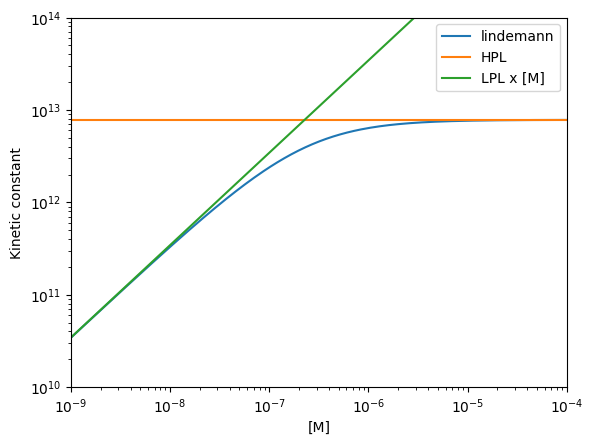

In [3]:
P_range = jnp.logspace(-5, 2, 300)

hpl = rate_constant.hpl.kinetic_constant(jnp.array([1000]*300)) # Compute the value of the HPL
lpl = rate_constant.lpl.kinetic_constant(jnp.array([1000]*300)) # Compute the value of the LPL
k, M = rate_constant.kinetic_constant(1000, P_range) # Kinetic constant here returns also M just to ease subsequent plotting stuff

fig, ax = plt.subplots()

ax.plot(M, k, label="lindemann")
ax.plot(M, hpl, label="HPL")
ax.plot(M, lpl*M, label="LPL x [M]")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([1e-9, 1e-4])
ax.set_ylim([1e10, 1e14])
ax.set_xlabel("[M]")
ax.set_ylabel("Kinetic constant")
ax.legend()
plt.show()

## TROE
- Equations
    > $F = 10^{\left(\dfrac{log_{10}Fcent}{1 + f_{1}^2}\right)}$
    > 
    > $Fcent = (1-A) exp\left(-\dfrac{T}{T_3}\right) + Aexp\left(-\dfrac{T}{T_1}\right) + exp\left(\dfrac{T_2}{T}\right)$
    >
    > $f_1 = \dfrac{log_{10}P_{r} + c}{n - 0.14\left(log_{10}P_{r} + c\right)}$
    >
    > $c = -0.4 - 0.67log_{10}Fcent$
    >
    > $n = 0.75 - 1.27 log_{10}Fcent$
- CHEMKIN representation
    >```
    > CH3 + CH3(+M) = C2H6(+M)   9.030E+16 -1.180 654.000 
    >  LOW /                     3.180E+41 -7.030 2762.00 /
    > TROE / 0.6041 6927.00 132.00 0.000                  / ! TROE fall-off coefficients
    > H2/ 2/ CO/ 2/ CO2/ 3/ H2O/ 5/                         ! enhanced third-body efficiencies
    >```
- Internal representation
    >```python
    >troe_constant = {
    >    "name": "CH3+CH3(+M)=C2H6(+M)",
    >    "type": "falloff",
    >    "falloff-type": "troe",
    >    "rate-constant": {
    >        "lpl-coefficients": [9.030e+16, -1.180, 654.000],
    >        "hpl-coefficients": [6.369e+27, -2.760, -54.000],
    >        "falloff-coefficients": [0.6041, 6927.00, 132.00],
    >    },
    >    "efficiencies": {"H2": 2, "CO": 2, "CO2": 3, "H2O": 5}
    >}

In [4]:
# --------------------------------------------------------
# Dictionary initialization
# --------------------------------------------------------
troe_constant = {
    "name": "2CH3(+M)=C2H6(+M)",
    "type": "falloff",
    "falloff-type": "troe",
    "rate-constant": {
        "lpl-coefficients": [3.400E+41, -7.030, 2762.00],
        "hpl-coefficients": [6.770E+16, -1.180, 654.00],
        "falloff-coefficients": [0.619, 73.20, 1180, 9999.00],
    },
    "efficiencies": {"H2": 2, "CO": 2, "CO2": 3, "H2O": 5}
}
rate_constant = FallOff(troe_constant)

# --------------------------------------------------------
# Parameters initialization
# --------------------------------------------------------
rate_constant = FallOff(
    name="2CH3(+M)=C2H6(+M)",
    hpl_params=[6.770E+16, -1.180, 654.00],
    lpl_params=[3.400E+41, -7.030, 2762.00],
    falloff_params=[0.619, 73.20, 1180, 9999.00],
    falloff_type="troe",
    efficiencies={"H2": 2, "CO": 2, "CO2": 3, "H2O": 5},
)

## Kinetic constant computation

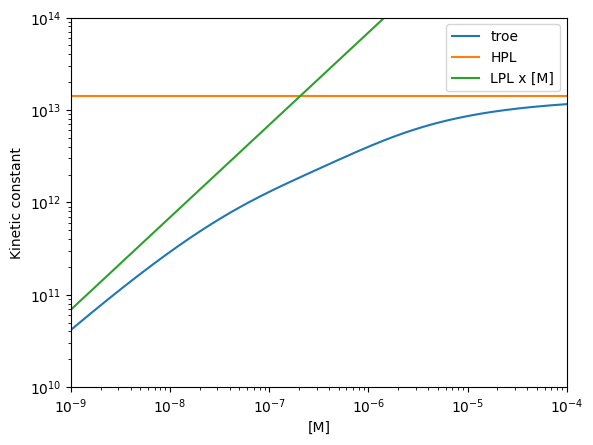

In [5]:
T_range = jnp.array([1000]*300)
P_range = jnp.logspace(-5, 2, 300)

hpl = rate_constant.hpl.kinetic_constant(jnp.array([1000]*300)) # Compute the value of the HPL
lpl = rate_constant.lpl.kinetic_constant(jnp.array([1000]*300)) # Compute the value of the LPL
k, M = rate_constant.kinetic_constant(1000, P_range) # Kinetic constant here returns also M just to ease subsequent plotting stuff

fig, ax = plt.subplots()

ax.plot(M, k, label="troe")
ax.plot(M, hpl, label="HPL")
ax.plot(M, lpl*M, label="LPL x [M]")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([1e-9, 1e-4])
ax.set_ylim([1e10, 1e14])
ax.set_xlabel("[M]")
ax.set_ylabel("Kinetic constant")
ax.legend()
plt.show()

## SRI
- Equations
    > $F = d\left[a\times exp\left(-b/T\right) + exp\left(-T/c\right)\right]^{\chi} T^{e}$
    > 
    > $\chi = \dfrac{1}{1 + log_{10}^{2}P_{r}}$
- CHEMKIN representation
    >```
    > CH3 + H(+M) = CH4(+M)      6.000E+16 -1.000 0.000 
    >  LOW /                     8.000E+26 -3.000 0.000 /
    > SRI  / 0.450 797.00 979.00 1.000 0.000            / ! SRI fall-off coefficients
    > H2/ 2/ CO/ 2/ CO2/ 3/ H2O/ 5/                       ! enhanced third-body efficiencies
    >```
- Internal representation
    >```python
    >sri_constant = {
    >    "name": "CH3+H(+M)=CH4(+M)",
    >    "type": "falloff",
    >    "falloff-type": "sri",
    >    "rate-constant": {
    >        "lpl-coefficients": [6.000e+16, -1.000, 0.000],
    >        "hpl-coefficients": [8.000e+26, -3.000, 0.000],
    >        "falloff-coefficients": [0.450, 797.00, 979.00, 1., 0.],
    >    },
    >    "efficiencies": {"H2": 2, "CO": 2, "CO2": 3, "H2O": 5}
    >}

In [6]:
# --------------------------------------------------------
# Dictionary initialization
# --------------------------------------------------------
sri_constant = {
   "name": "CH3+H(+M)=CH4(+M)",
   "type": "falloff",
   "falloff-type": "sri",
   "rate-constant": {
       "lpl-coefficients": [6.000e+16, -1.000, 0.000],
       "hpl-coefficients": [8.000e+26, -3.000, 0.000],
       "falloff-coefficients": [0.450, 797.00, 979.00, 1., 0.],
   },
   "efficiencies": {"H2": 2, "CO": 2, "CO2": 3, "H2O": 5}
}
rate_constant = FallOff(sri_constant)

# --------------------------------------------------------
# Parameters initialization
# --------------------------------------------------------
rate_constant = FallOff(
    name="CH3+H(+M)=CH4(+M)",
    hpl_params=[8.000e+26, -3.000, 0.000],
    lpl_params=[6.000e+16, -1.000, 0.000],
    falloff_params=[0.450, 797.00, 979.00, 1., 0.],
    falloff_type="sri",
    efficiencies={"H2": 2, "CO": 2, "CO2": 3, "H2O": 5},
)